In [243]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import re
import pandas as pd
from datetime import datetime

In [244]:
# scrollbars für alle outputs deaktivieren

from IPython.display import HTML
HTML("""
<style>
.jp-OutputArea-output {
    max-height: none !important;
}
.jp-OutputArea {
    max-height: none !important;
}
</style>
""")

# 1. MANUAL WORK BEFORE RUNNING THE SCRIPT: 
1. add year in file names: only "2025" at the end
2. adjust path to files: the variable data_folder
3. for copying the text analysis: right click + first position: "copy output to clipboard"

# 2. ANALYSIS

In [245]:
# Folder with your raw CSV files
data_folder = "/Users/christiangroeger/Desktop/KI-Campus/yuzhi/Course_completion_rates_all_files"

In [246]:
# date extraction helper
def extract_date_from_filename(filename):
    match = re.search(r'\((\d{2})\.(\d{2})\.(\d{4})', filename)
    if match:
        day, month, year = match.groups()
        return datetime.strptime(f"{day}.{month}.{year}", "%d.%m.%Y")
    return None


In [247]:

# Create cleaned folder: create path
cleaned_folder = os.path.join(data_folder, "cleaned")
os.makedirs(cleaned_folder, exist_ok=True)

In [248]:


# find the right files in the destination folder (csv files with a date ending like:  data(12.03.csv)
# save the names into a list "filenames"

# List all files by extracted date
filenames = [
    f for f in os.listdir(data_folder)
    if extract_date_from_filename(f) is not None
]

print("📂 Found files:", filenames)



📂 Found files: ['KIC-course completion rate(28.07.2025.csv', 'KIC-course completion rate(26.08.2025.csv', 'KIC-course completion rate(28.10.2025.csv', 'KIC-course completion rate(26.09.2025.csv', 'KIC-course completion rate(23.06.2025.csv', 'KIC-course completion rate(21.05.2025.csv']


In [249]:
for f in filenames:
    file_path = os.path.join(data_folder, f)
    date = extract_date_from_filename(f)

    df = pd.read_csv(file_path, sep=";", decimal=",", encoding="utf-8-sig")

    # Clean column names
    df.columns = (
        df.columns.str.strip()
                   .str.replace(" ", "_")
                   .str.replace(r"^\ufeff", "", regex=True)
    )

    # Add Date + Month
    df["Date"] = date
    df["Month"] = date.strftime("%b")
    # create a column with month labels
    df["MonthLabel"] = df["Date"].dt.strftime("%b %y")

    # Columns that may contain percentages like "5%"
    percent_columns = ["Rate_CoP", "Rate_RoA_(success)"]

    for col in percent_columns:
        if col in df.columns:
            df[col] = (
                df[col].astype(str)
                       .str.replace("%", "", regex=False)
                       .str.replace(",", ".", regex=False)
                       .str.strip()
            )
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    # Other numeric columns
    numeric_columns = [
        "Enrolled_learners",
        "Acquired_#_Comfirmation_of_Participations",
        "Acquired_#_Records_of_Achievement",
    ]

    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    # Save cleaned CSV
    cleaned_path = os.path.join(cleaned_folder, f)
    df.to_csv(cleaned_path, sep=";", decimal=",", index=False, encoding="utf-8")

df.head()

,courseID,Live_Courses,Course_Category,Enrolled_learners,Acquired_#_Comfirmation_of_Participations,Acquired_#_Records_of_Achievement,Rate_CoP,Rate_RoA_(success),Date,Month,MonthLabel
0,106.0,Einführung in die KI,Über KI,7738.0,1086.0,823.0,14.0,11.0,2025-05-21,May,May 25
1,19.0,Sprachassistenzen als Chance für die Hochschul...,Erwachsenenbildung,3652.0,514.0,460.0,14.0,13.0,2025-05-21,May,May 25
2,58.0,AICE your exams – Generative KI als Copilot im...,Studieren,2767.0,573.0,105.0,21.0,4.0,2025-05-21,May,May 25
3,99.0,KI für Alle 1: Einführung in die Künstliche In...,Über KI,2761.0,202.0,119.0,7.0,4.0,2025-05-21,May,May 25
4,27.0,Identifikation geeigneter KI-Anwendungsfälle,Industrie 4.0,2691.0,183.0,185.0,7.0,7.0,2025-05-21,May,May 25


In [250]:
# Loads ALL cleaned files once, fixes BOM, normalizes column names, returns dict of DataFrames
def load_clean_files(cleaned_folder):
    """
    Loads all cleaned CSV files, fixes BOM + spacing, stores them in a dict.
    Dict structure: {filename: dataframe}
    """
    dfs = {}

    # sort files chronologically
    sorted_files = sorted(
        [f for f in os.listdir(cleaned_folder)
         if extract_date_from_filename(f) is not None],
        key=lambda f: extract_date_from_filename(f)
    )

    for f in sorted_files:
        path = os.path.join(cleaned_folder, f)

        df = pd.read_csv(path, sep=";", decimal=",", encoding="utf-8-sig")


        dfs[f] = df

    print(f"📁 Loaded {len(dfs)} cleaned files.")
    return dfs

dfs = load_clean_files(cleaned_folder)



📁 Loaded 6 cleaned files.


In [251]:
for filename, df in dfs.items():
    print("📄 File:", filename)
    print("➡️ Columns:", list(df.columns))
    print()

📄 File: KIC-course completion rate(21.05.2025.csv
➡️ Columns: ['courseID', 'Live_Courses', 'Course_Category', 'Enrolled_learners', 'Acquired_#_Comfirmation_of_Participations', 'Acquired_#_Records_of_Achievement', 'Rate_CoP', 'Rate_RoA_(success)', 'Date', 'Month', 'MonthLabel']

📄 File: KIC-course completion rate(23.06.2025.csv
➡️ Columns: ['courseID', 'Live_Courses', 'Course_Category', 'Enrolled_learners', 'Acquired_#_Comfirmation_of_Participations', 'Acquired_#_Records_of_Achievement', 'Rate_CoP', 'Rate_RoA_(success)', 'Date', 'Month', 'MonthLabel']

📄 File: KIC-course completion rate(28.07.2025.csv
➡️ Columns: ['courseID', 'Live_Courses', 'Course_Category', 'Enrolled_learners', 'Acquired_#_Comfirmation_of_Participations', 'Acquired_#_Records_of_Achievement', 'Rate_CoP', 'Rate_RoA_(success)', 'Date', 'Month', 'MonthLabel']

📄 File: KIC-course completion rate(26.08.2025.csv
➡️ Columns: ['courseID', 'Live_Courses', 'Course_Category', 'Enrolled_learners', 'Acquired_#_Comfirmation_of_Part

# ANALYSIS QUESTION: monthly totals: enrolments + avg RoA rate

In [252]:
# helper function: pretty table printer (needed only once)

def print_table(title, rows):
    print(f"\n{title}")
    print("-" * len(title))
    
    # compute col widths
    col1 = max(len(r[0]) for r in rows)
    col2 = max(len(r[1]) for r in rows)

    print(f"{'Metric'.ljust(col1)} | {'Value'.ljust(col2)}")
    print(f"{'-'*col1}-+-{'-'*col2}")

    for metric, value in rows:
        print(f"{metric.ljust(col1)} | {value.ljust(col2)}")
    print()

# helper functionr: report section printer (needed only once)
today = datetime.today().strftime("%Y-%m-%d")

def print_section(question, narrative, table_rows):
    print("="*80)
    print(f"DATE: {today}")
    #print("ANALYSIS QUESTION")
    print()
    print(question)
    print("="*80)
    
    print()

    print_table("Summary Table", table_rows)

    print("Interpretation")
    print("--------------")
    print(narrative)
    print("="*80)
    print()


In [253]:
##  net enrolments difference per month + RoA rate per month

def get_monthly_totals(dfs):
    """
    Computes monthly totals and adds:
    - Absolute month-to-month change in enrolments (Δ_Enrolments_abs)
    - Relative month-to-month change in enrolments (Δ_Enrolments_%)
    """

    monthly_data = []

    for f, df in dfs.items():

        date = extract_date_from_filename(f)
        month = df["Month"].iloc[0]
        month_label = df["MonthLabel"].iloc[0]

        total_enrol = df["Enrolled_learners"].sum()
        avg_roa = df["Rate_RoA_(success)"].mean()

        monthly_data.append({
            "MonthLabel": month_label,
            "Date": date,
            "Month": month,
            "Total_Enrolments": total_enrol,
            "Average_RoA(%)": round(avg_roa, 2)
        })

    # Sort chronologically
    monthly_df = (
        pd.DataFrame(monthly_data)
        .sort_values("Date")
        .reset_index(drop=True)
    )

    # ---------------------------------------------
    # Compute differences between months
    # ---------------------------------------------
    monthly_df["Δ_Enrolments_abs"] = monthly_df["Total_Enrolments"].diff()

    # Percentage change
    monthly_df["Δ_Enrolments_%"] = (
        monthly_df["Total_Enrolments"].pct_change() * 100
    ).round(2)

    return monthly_df


# Run it
monthly_df = get_monthly_totals(dfs)
monthly_df


,MonthLabel,Date,Month,Total_Enrolments,Average_RoA(%),Δ_Enrolments_abs,Δ_Enrolments_%
0,May 25,2025-05-21,May,55507.0,9.45,NaN,NaN
1,Jun 25,2025-06-23,Jun,66968.0,11.56,11461.0,20.65
2,Jul 25,2025-07-28,Jul,69711.0,14.04,2743.0,4.10
3,Aug 25,2025-08-26,Aug,76808.0,5.92,7097.0,10.18
4,Sep 25,2025-09-26,Sep,86982.0,14.98,10174.0,13.25
5,Oct 25,2025-10-28,Oct,100208.0,13.55,13226.0,15.21


In [254]:

def analyze_monthly_totals(monthly_df):

    df = monthly_df.sort_values("Date")

    # ---------------------------------------------------------
    # ENROLMENT CHANGE ANALYSIS (instead of total enrolments)
    # ---------------------------------------------------------
    # Note: first month will have NaN Δ → exclude it
    df_changes = df.dropna(subset=["Δ_Enrolments_abs"])

    # Month with largest increase
    peak_row = df_changes.loc[df_changes["Δ_Enrolments_abs"].idxmax()]

    # Month with largest decrease
    low_row  = df_changes.loc[df_changes["Δ_Enrolments_abs"].idxmin()]

    # ---------------------------------------------------------
    # RoA ANALYSIS (unchanged)
    # ---------------------------------------------------------
    avg_roa_overall = round(df["Average_RoA(%)"].mean(), 2)

    roa_start = df["Average_RoA(%)"].iloc[0]
    roa_end   = df["Average_RoA(%)"].iloc[-1]

    if roa_end > roa_start:
        roa_trend = "rising over time"
    elif roa_end < roa_start:
        roa_trend = "declining over time"
    else:
        roa_trend = "stable over time"

    # Correlation between RoA and NET change
    corr = df_changes["Δ_Enrolments_abs"].corr(df_changes["Average_RoA(%)"])

    if corr > 0.3:
        corr_type = "moderate positive correlation"
    elif corr < -0.3:
        corr_type = "moderate negative correlation"
    else:
        corr_type = "no strong correlation"


    # ---------------------------------------------------------
    # Create summary table
    # ---------------------------------------------------------
    table_rows = [
        ("Largest Increase in Enrolments", 
         f"{peak_row['MonthLabel']} ({peak_row['Δ_Enrolments_abs']:+.0f})"),

        ("Largest Decrease in Enrolments",  
         f"{low_row['MonthLabel']} ({low_row['Δ_Enrolments_abs']:+.0f})"),

        ("Average RoA (%) overall",         f"{avg_roa_overall}%"),
        ("RoA Trend",               roa_trend),
        ("Δ-Enrolments – RoA Correlation", corr_type)
    ]


    # ---------------------------------------------------------
    # Narrative text
    # ---------------------------------------------------------
    narrative = (
        f"The month with the strongest increase in enrolments was {peak_row['MonthLabel']}, "
        f"with a net change of {peak_row['Δ_Enrolments_abs']:+.0f} learners. "
        f"The largest decrease occurred in {low_row['MonthLabel']}, "
        f"with {low_row['Δ_Enrolments_abs']:+.0f} learners compared to the previous month. "
        f"The average Rate of Achievement (RoA) across all months is {avg_roa_overall}%. "
        f"RoA appears to be {roa_trend}, suggesting a consistent performance trend over time. "
        f"There is {corr_type} between enrolment changes and RoA, "
        f"indicating that fluctuations in learner numbers do not necessarily drive changes in success rates."
    )

    return table_rows, narrative

# automatically generate full printed section

question_2 = "How do the total enrolments and the average RoA evolve across the months?"

table_rows_2, narrative_2 = analyze_monthly_totals(monthly_df)

print_section(question_2, narrative_2, table_rows_2)


DATE: 2025-12-08

How do the total enrolments and the average RoA evolve across the months?


Summary Table
-------------
Metric                         | Value                
-------------------------------+----------------------
Largest Increase in Enrolments | Oct 25 (+13226)      
Largest Decrease in Enrolments | Jul 25 (+2743)       
Average RoA (%) overall        | 11.58%               
RoA Trend                      | rising over time     
Δ-Enrolments – RoA Correlation | no strong correlation

Interpretation
--------------
The month with the strongest increase in enrolments was Oct 25, with a net change of +13226 learners. The largest decrease occurred in Jul 25, with +2743 learners compared to the previous month. The average Rate of Achievement (RoA) across all months is 11.58%. RoA appears to be rising over time, suggesting a consistent performance trend over time. There is no strong correlation between enrolment changes and RoA, indicating that fluctuations in learner numbe

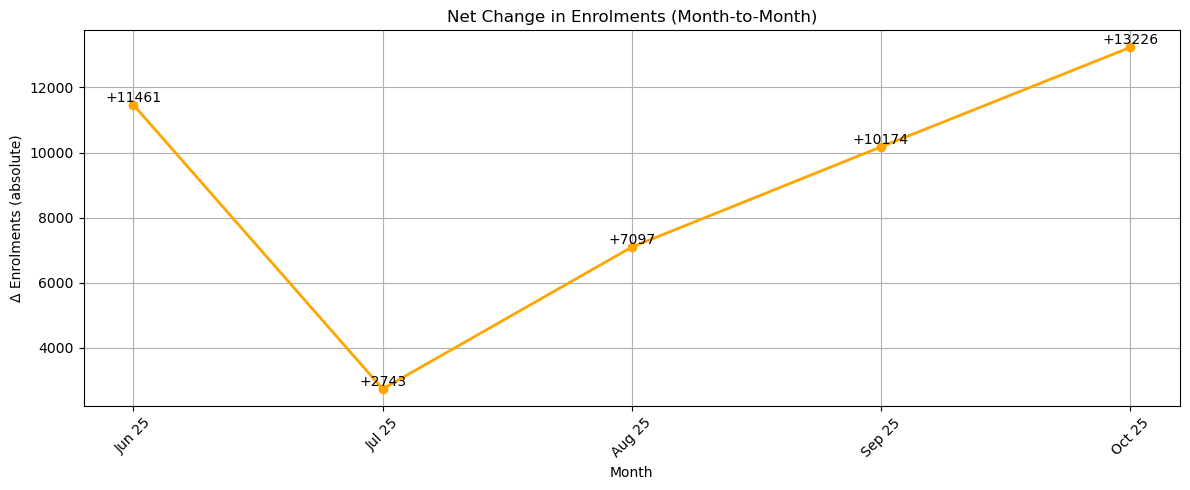

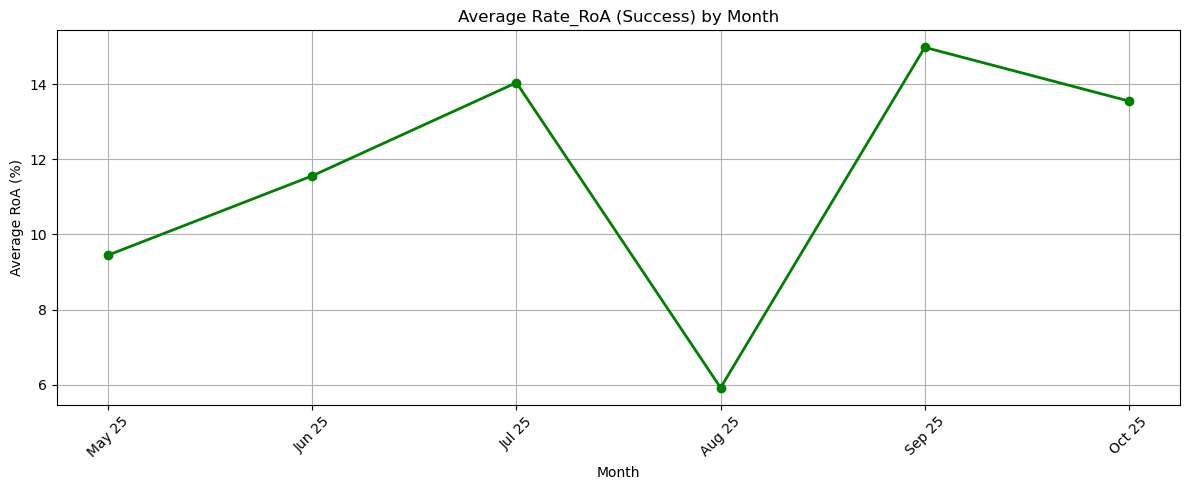

In [255]:
def plot_all_files(monthly_df):
    """
    Plots:
    1. Total enrolments per month (line)
    2. Net month-to-month enrolment change (line, annotated)
    3. Net month-to-month enrolment change (bar, annotated)
    4. Average RoA per month (line)
    """



    # ----------------------------------------------------------
    # Plot 2: Net Enrolment Difference (line) + ANNOTATIONS
    # ----------------------------------------------------------
    x = monthly_df["MonthLabel"]
    y = monthly_df["Δ_Enrolments_abs"]

    plt.figure(figsize=(12,5))
    plt.plot(x, y, marker="o", linewidth=2, color="orange")
    plt.title("Net Change in Enrolments (Month-to-Month)")
    plt.xlabel("Month")
    plt.ylabel("Δ Enrolments (absolute)")
    plt.grid(True)
    plt.xticks(rotation=45)

    # ---- annotations for each point ----
    for i, value in enumerate(y):
        if pd.notna(value):
            plt.text(
                i, value,
                f"{value:+.0f}",       # + sign for increases
                ha='center', va='bottom' if value >= 0 else 'top',
                fontsize=10, color="black"
            )

    plt.tight_layout()
    plt.show()





    # --------------------------------
    # Plot 4: Average RoA (%)
    # --------------------------------
    plt.figure(figsize=(12,5))
    plt.plot(
        monthly_df["MonthLabel"], 
        monthly_df["Average_RoA(%)"],
        marker="o", linewidth=2, color="green"
    )
    plt.title("Average Rate_RoA (Success) by Month")
    plt.xlabel("Month")
    plt.ylabel("Average RoA (%)")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_all_files(monthly_df)

In [256]:
df.columns

Index(['courseID', 'Live_Courses', 'Course_Category', 'Enrolled_learners',
       'Acquired_#_Comfirmation_of_Participations',
       'Acquired_#_Records_of_Achievement', 'Rate_CoP', 'Rate_RoA_(success)',
       'Unnamed:_8', 'Unnamed:_9', 'Unnamed:_10', 'Unnamed:_11', 'Date',
       'Month', 'MonthLabel'],
      dtype='object')

In [257]:
# Build a combined dataframe of all courses
def combine_all_courses(dfs):
    all_rows = []

    for fname, df in dfs.items():
        date = extract_date_from_filename(fname)
        df = df.copy()
        df["Filename"] = fname
        df["Date"] = date
        all_rows.append(df)

    combined = pd.concat(all_rows, ignore_index=True)
    return combined


combined_df = combine_all_courses(dfs)
combined_df.head()


,courseID,Live_Courses,Course_Category,Enrolled_learners,Acquired_#_Comfirmation_of_Participations,Acquired_#_Records_of_Achievement,Rate_CoP,Rate_RoA_(success),Date,Month,MonthLabel,Filename,Unnamed:_8,Unnamed:_9,Unnamed:_10,Unnamed:_11
0,106.0,Einführung in die KI,Über KI,7738.0,1086.0,823.0,14.0,11.0,2025-05-21,May,May 25,KIC-course completion rate(21.05.2025.csv,NaN,NaN,NaN,NaN
1,19.0,Sprachassistenzen als Chance für die Hochschul...,Erwachsenenbildung,3652.0,514.0,460.0,14.0,13.0,2025-05-21,May,May 25,KIC-course completion rate(21.05.2025.csv,NaN,NaN,NaN,NaN
2,58.0,AICE your exams – Generative KI als Copilot im...,Studieren,2767.0,573.0,105.0,21.0,4.0,2025-05-21,May,May 25,KIC-course completion rate(21.05.2025.csv,NaN,NaN,NaN,NaN
3,99.0,KI für Alle 1: Einführung in die Künstliche In...,Über KI,2761.0,202.0,119.0,7.0,4.0,2025-05-21,May,May 25,KIC-course completion rate(21.05.2025.csv,NaN,NaN,NaN,NaN
4,27.0,Identifikation geeigneter KI-Anwendungsfälle,Industrie 4.0,2691.0,183.0,185.0,7.0,7.0,2025-05-21,May,May 25,KIC-course completion rate(21.05.2025.csv,NaN,NaN,NaN,NaN


Correlation: Enrolments vs RoA RATE 0.15121033746601986
Correlation: Enrolments vs RoA count 0.7917551636709071


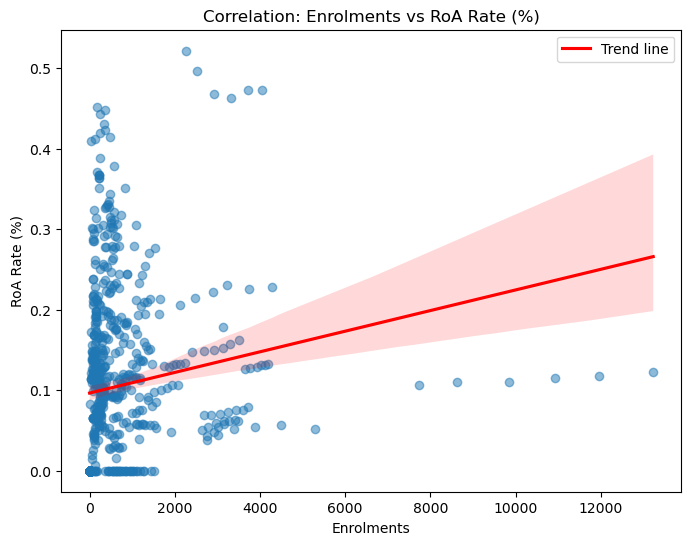

In [258]:
# question: is there correlation between enrolments and RoA?

# compute RoA rate per row
df = combined_df.copy()

df["RoA_Rate"] = (
    df["Acquired_#_Records_of_Achievement"] / df["Enrolled_learners"]
).replace([np.inf, -np.inf], np.nan).fillna(0)

# correlate

corr_rate = df["Enrolled_learners"].corr(df["RoA_Rate"])
corr_abs  = df["Enrolled_learners"].corr(df["Acquired_#_Records_of_Achievement"])

print("Correlation: Enrolments vs RoA RATE", corr_rate)
print("Correlation: Enrolments vs RoA count", corr_abs)

# visualisation
plt.figure(figsize=(8,6))

ax = sns.regplot(
    data=df,
    x="Enrolled_learners",
    y="RoA_Rate",
    scatter_kws={"alpha":0.5, "label": "Courses"},
    line_kws={"color":"red", "label": "Trend line"}
)

plt.title("Correlation: Enrolments vs RoA Rate (%)")
plt.xlabel("Enrolments")
plt.ylabel("RoA Rate (%)")

# Add legend
plt.legend()

plt.show()


# ANALYSIS QUESTION: top-10 courses: by enrolments and by RoA

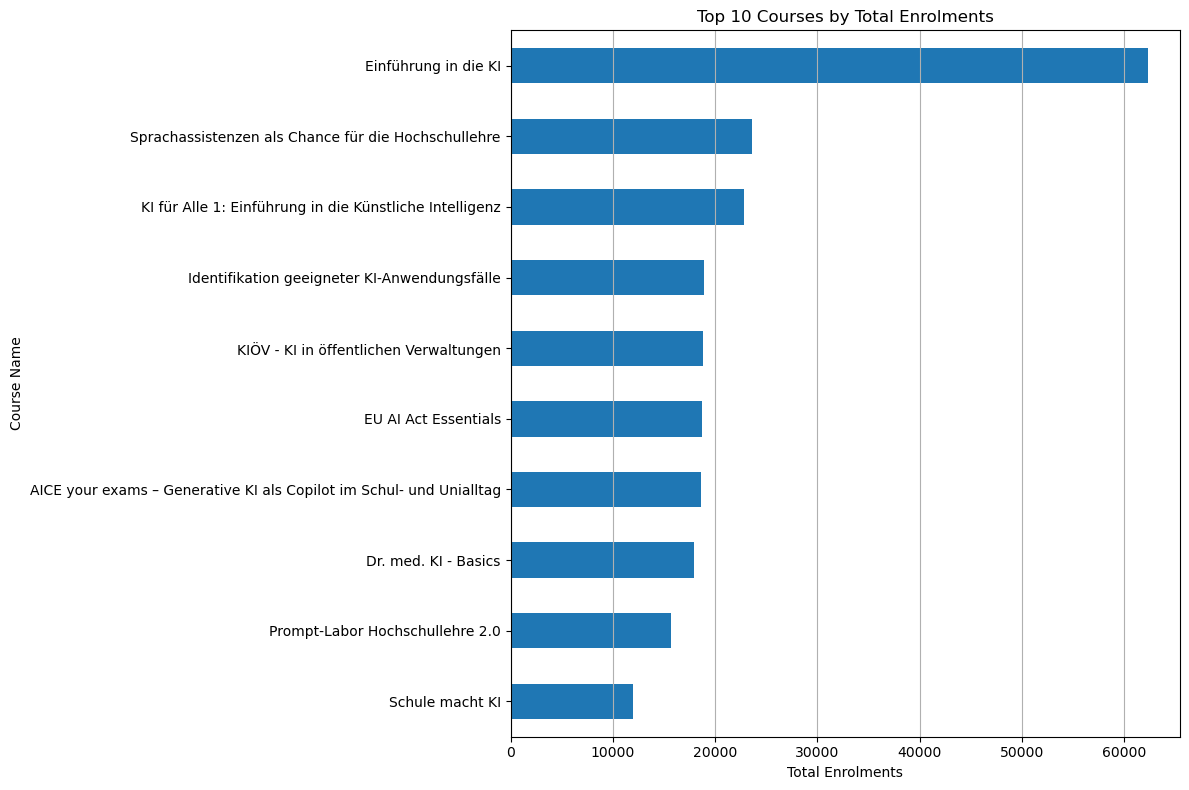

In [259]:
### TOTAL ENROLMENTS AND TOTAL ROA NUMBERS FOR TOP 10 COURSES ###

# Find Top-10 courses by:

# total enrolments
top10_enrol = (
    combined_df.groupby("Live_Courses")["Enrolled_learners"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


# Plotting function for Top-10
def plot_top10_horizontal(title, series, xlabel):
    plt.figure(figsize=(12, 8))

    # Plot as horizontal bar chart
    series.sort_values().plot(kind="barh")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Course Name")
    plt.grid(axis="x")
    plt.tight_layout()
    plt.show()



# Final plots
# Total enrolments (Top 10)
plot_top10_horizontal(
    "Top 10 Courses by Total Enrolments",
    top10_enrol,
    xlabel="Total Enrolments"
)






In [260]:
# analysis function for top-10 total enrolments

def analyze_top10_enrol(top10_enrol):
    # Convert to Series and ensure sorted
    ser = top10_enrol.sort_values(ascending=False)

    top_course = ser.index[0]
    top_value  = ser.iloc[0]

    bottom_course = ser.index[-1]
    bottom_value  = ser.iloc[-1]

    avg_top10 = round(ser.mean(), 2)

    table_rows = [
        ("Highest Enrolment Course", f"{top_course} ({top_value})"),
        ("Lowest in Top 10",         f"{bottom_course} ({bottom_value})"),
        ("Average Enrolments (Top10)", str(avg_top10)),
        ("Total Courses Considered", "10")
    ]

    narrative = (
        f"The course with the highest total enrolments is **{top_course}**, "
        f"with {top_value} learners. The course with the lowest enrolments "
        f"among the Top-10 is **{bottom_course}**, with {bottom_value} learners. "
        f"On average, the Top-10 courses have {avg_top10} enrolments, "
        f"indicating that the most popular courses attract significantly larger "
        f"audiences than the rest of the catalogue."
    )

    return table_rows, narrative

# analysis function for top-10 average RoA

def analyze_top10_roa(top10_roa):
    ser = top10_roa.sort_values(ascending=False)

    top_course = ser.index[0]
    top_value  = round(ser.iloc[0], 2)

    bottom_course = ser.index[-1]
    bottom_value  = round(ser.iloc[-1], 2)

    avg_top10 = round(ser.mean(), 2)

    table_rows = [
        ("Highest Achieving Course", f"{top_course} ({top_value}%)"),
        ("Lowest in Top 10",         f"{bottom_course} ({bottom_value}%)"),
        ("Average RoA (Top10)",      f"{avg_top10}%"),
        ("Total Courses Considered", "10")
    ]

    narrative = (
        f"The course with the highest average RoA is **{top_course}**, "
        f"with an RoA of {top_value}%. The lowest-performing course among "
        f"the Top-10 is **{bottom_course}** at {bottom_value}%. "
        f"Overall, the Top-10 courses achieve an average RoA of {avg_top10}%, "
        f"suggesting that the top courses not only attract many learners but "
        f"also maintain high levels of learner success."
    )

    return table_rows, narrative

# re-use print_section function from earlier





In [261]:
# generate both report sections automatically

question_3 = "Which courses have the highest total enrolments?"

table_rows_3, narrative_3 = analyze_top10_enrol(top10_enrol)

print_section(question_3, narrative_3, table_rows_3)


DATE: 2025-12-08

Which courses have the highest total enrolments?


Summary Table
-------------
Metric                     | Value                         
---------------------------+-------------------------------
Highest Enrolment Course   | Einführung in die KI (62334.0)
Lowest in Top 10           | Schule macht KI (11959.0)     
Average Enrolments (Top10) | 22940.0                       
Total Courses Considered   | 10                            

Interpretation
--------------
The course with the highest total enrolments is **Einführung in die KI**, with 62334.0 learners. The course with the lowest enrolments among the Top-10 is **Schule macht KI**, with 11959.0 learners. On average, the Top-10 courses have 22940.0 enrolments, indicating that the most popular courses attract significantly larger audiences than the rest of the catalogue.



# ANALYSIS QUESTION: top-10 courses: by RoA¶

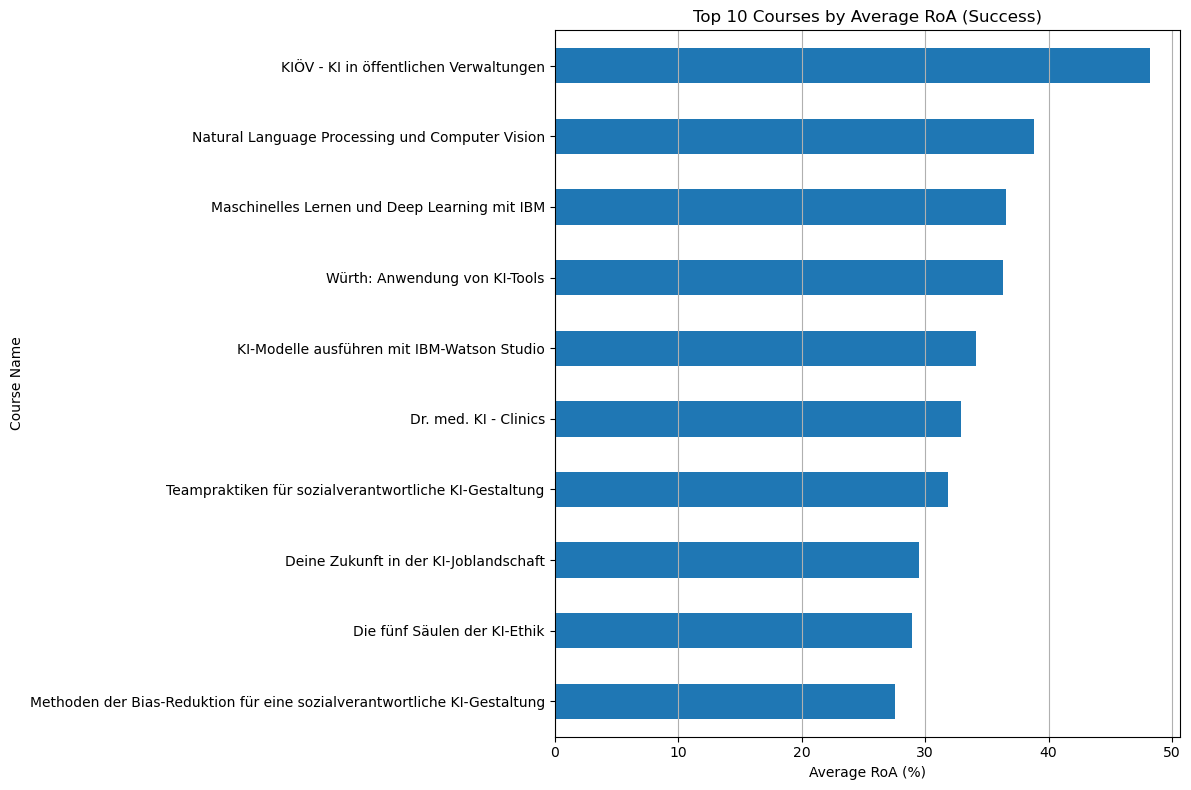

In [262]:

# Average RoA
top10_roa = (
    combined_df.groupby("Live_Courses")["Rate_RoA_(success)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Average RoA (Top 10)
plot_top10_horizontal(
    "Top 10 Courses by Average RoA (Success)",
    top10_roa,
    xlabel="Average RoA (%)"
)



In [263]:
question_4 = "Which courses have the highest average Rate of Achievement (RoA)?"

table_rows_4, narrative_4 = analyze_top10_roa(top10_roa)

print_section(question_4, narrative_4, table_rows_4)


DATE: 2025-12-08

Which courses have the highest average Rate of Achievement (RoA)?


Summary Table
-------------
Metric                   | Value                                                                            
-------------------------+----------------------------------------------------------------------------------
Highest Achieving Course | KIÖV - KI in öffentlichen Verwaltungen (48.22%)                                  
Lowest in Top 10         | Methoden der Bias-Reduktion für eine sozialverantwortliche KI-Gestaltung (27.58%)
Average RoA (Top10)      | 34.47%                                                                           
Total Courses Considered | 10                                                                               

Interpretation
--------------
The course with the highest average RoA is **KIÖV - KI in öffentlichen Verwaltungen**, with an RoA of 48.22%. The lowest-performing course among the Top-10 is **Methoden der Bias-Reduktion für eine soz

# ANALYSIS QUESTION: top-10 monthly enrolments: time series

In [264]:
# create df
# Top-10 Kurse bestimmen (IDs!)
top10_ids = (
    combined_df.groupby("Live_Courses")["Enrolled_learners"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# ALLE Zeilen dieser Kurse herausholen
top10_df = combined_df[combined_df["Live_Courses"].isin(top10_ids)]

# function for automatic plot creation: monthly enrolments time-series

def plot_top10_time_series(top10_df):
    plt.figure(figsize=(14, 8))

    # Ensure chronological order
    top10_df = top10_df.sort_values("Date")

    # Plot each course
    for course, group in top10_df.groupby("Live_Courses"):
        group = group.sort_values("Date")   # important!
        plt.plot(
            group["Date"],
            group["Enrolled_learners"],
            marker="o",
            linewidth=2,
            label=course
        )

    # --- FIX X-AXIS TICKS TO USE MonthLabel ---
    plt.xticks(
        ticks=top10_df["Date"].unique(),
        labels=top10_df["MonthLabel"].unique(),
        rotation=45
    )

    plt.title("Monthly Enrolments for Top 10 Courses")
    plt.xlabel("Month")
    plt.ylabel("Enrolled Learners")
    plt.grid(True)
    plt.legend(title="Course Name", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()




DATE: 2025-12-08

How do the enrolments of the Top-10 courses evolve over time, and what trends can be observed?


Summary Table
-------------
Metric                 | Value
-----------------------+---
Total Courses Analyzed | 10
Courses Increasing     | 9 
Courses Decreasing     | 1 
Courses Stable         | 0 

Interpretation
--------------
This time series analysis covers 10 courses with the highest total enrolments. Trends across the courses show that 9 courses exhibit increasing enrolment over time, 1 are declining, and 0 remain relatively stable. Individual courses show distinct seasonal or periodic fluctuations, and the peaks and troughs vary widely between courses, suggesting that learner engagement is course-specific and influenced by factors such as topic demand, release timing, and promotional activity.



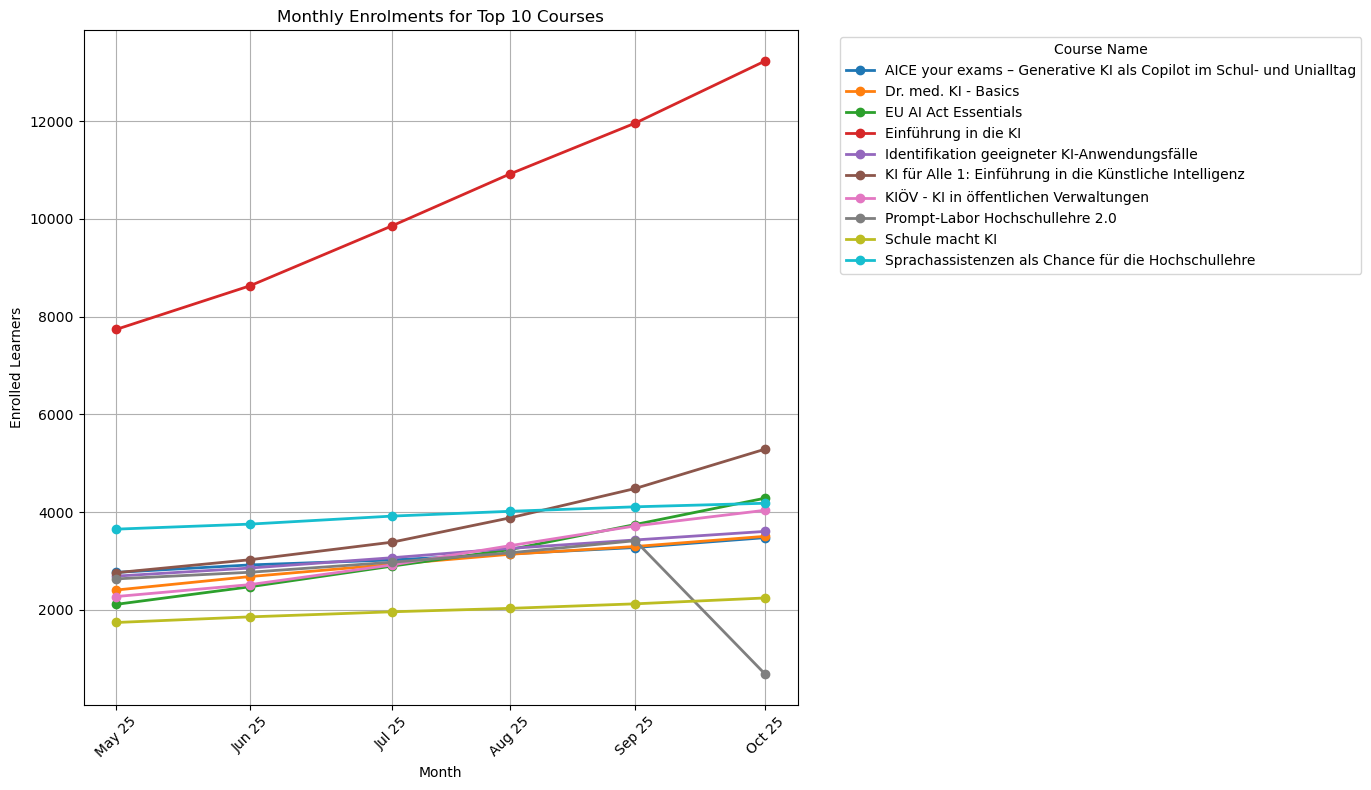

In [265]:
# automatic analysis function for top-10 time series

def analyze_top10_timeseries(top10_df):

    df = top10_df.sort_values("Date")

    summaries = []

    for course, group in df.groupby("Live_Courses"):

        group = group.sort_values("Date")

        # Peak month
        peak_row = group.loc[group["Enrolled_learners"].idxmax()]
        peak_month = peak_row["MonthLabel"]
        peak_value = int(peak_row["Enrolled_learners"])

        # Lowest month
        low_row = group.loc[group["Enrolled_learners"].idxmin()]
        low_month = low_row["MonthLabel"]
        low_value = int(low_row["Enrolled_learners"])

        # Trend direction
        start_val = group["Enrolled_learners"].iloc[0]
        end_val   = group["Enrolled_learners"].iloc[-1]

        if end_val > start_val:
            trend = "increasing"
        elif end_val < start_val:
            trend = "decreasing"
        else:
            trend = "stable"

        summaries.append({
            "course": course,
            "peak_month": peak_month,
            "peak_value": peak_value,
            "low_month": low_month,
            "low_value": low_value,
            "trend": trend
        })

    # Summary table for the entire Top 10
    total_courses = len(summaries)

    # Identify strongest trend
    trend_counts = {
        "increasing": sum(1 for s in summaries if s["trend"] == "increasing"),
        "decreasing": sum(1 for s in summaries if s["trend"] == "decreasing"),
        "stable":     sum(1 for s in summaries if s["trend"] == "stable")
    }

    table_rows = [
        ("Total Courses Analyzed", str(total_courses)),
        ("Courses Increasing", str(trend_counts["increasing"])),
        ("Courses Decreasing", str(trend_counts["decreasing"])),
        ("Courses Stable",     str(trend_counts["stable"]))
    ]

    # Build narrative
    narrative = (
        f"This time series analysis covers {total_courses} courses with the highest total "
        f"enrolments. Trends across the courses show that "
        f"{trend_counts['increasing']} courses exhibit increasing enrolment over time, "
        f"{trend_counts['decreasing']} are declining, and "
        f"{trend_counts['stable']} remain relatively stable. "
        "Individual courses show distinct seasonal or periodic fluctuations, and the peaks "
        "and troughs vary widely between courses, suggesting that learner engagement is "
        "course-specific and influenced by factors such as topic demand, release timing, "
        "and promotional activity."
    )

    return summaries, table_rows, narrative

# pretty-print functions defined above


# print the analysis for the top-10 time-series plot

question_5 = (
    "How do the enrolments of the Top-10 courses evolve over time, "
    "and what trends can be observed?"
)

summaries_5, table_rows_5, narrative_5 = analyze_top10_timeseries(top10_df)

print_section(question_5, narrative_5, table_rows_5)

# plot 
plot_top10_time_series(top10_df)

# ANALYSIS QUESTION: top-10 RoA time series

In [266]:
# automatic analysis function for top-10 RoA time series

def analyze_top10_roa_timeseries(combined_df):

    df = combined_df.copy()
    df = df.sort_values("Date")
    df["MonthLabel"] = df["Date"].dt.strftime("%b %y")

    # Top-10 courses by average RoA
    top10_list = (
        df.groupby("Live_Courses")["Rate_RoA_(success)"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
        .index
    )

    top10_df = df[df["Live_Courses"].isin(top10_list)].sort_values("Date")

    summaries = []

    for course, group in top10_df.groupby("Live_Courses"):
        group = group.sort_values("Date")

        # Peak RoA
        peak_row = group.loc[group["Rate_RoA_(success)"].idxmax()]
        peak_month = peak_row["MonthLabel"]
        peak_value = round(peak_row["Rate_RoA_(success)"], 2)

        # Lowest RoA
        low_row = group.loc[group["Rate_RoA_(success)"].idxmin()]
        low_month = low_row["MonthLabel"]
        low_value = round(low_row["Rate_RoA_(success)"], 2)

        # Trend
        start_val = group["Rate_RoA_(success)"].iloc[0]
        end_val   = group["Rate_RoA_(success)"].iloc[-1]

        if end_val > start_val:
            trend = "increasing"
        elif end_val < start_val:
            trend = "decreasing"
        else:
            trend = "stable"

        summaries.append({
            "course": course,
            "peak_month": peak_month,
            "peak_value": peak_value,
            "low_month": low_month,
            "low_value": low_value,
            "trend": trend
        })

    # Global summary
    trend_counts = {
        "increasing": sum(s["trend"] == "increasing" for s in summaries),
        "decreasing": sum(s["trend"] == "decreasing" for s in summaries),
        "stable":     sum(s["trend"] == "stable"     for s in summaries),
    }

    table_rows = [
        ("Total Courses Analyzed", "10"),
        ("Courses with Increasing RoA", str(trend_counts["increasing"])),
        ("Courses with Decreasing RoA", str(trend_counts["decreasing"])),
        ("Courses with Stable RoA",     str(trend_counts["stable"])),
    ]

    # Narrative
    narrative = (
        f"This time-series analysis examines the 10 courses with the highest overall "
        f"average RoA. Among these, {trend_counts['increasing']} courses show an "
        f"increasing trend in RoA over time, while {trend_counts['decreasing']} "
        f"courses show a decreasing trend. The remaining {trend_counts['stable']} "
        f"courses maintain relatively stable RoA values across all months. "
        "The variability in RoA development highlights differences in course structure, "
        "learner engagement, and topic difficulty—some courses consistently achieve "
        "high success, while others fluctuate or slowly decline."
    )

    return summaries, table_rows, narrative

# pretty-print functions defined above


In [267]:
### Top-10 RoA time-series plot ###

def plot_top10_roa_time_series(combined_df):

    df = combined_df.copy()
    df["MonthLabel"] = df["Date"].dt.strftime("%b %y")   # Mar 25

    # Top-10 courses by average RoA
    top10_roa_courses = (
        df.groupby("Live_Courses")["Rate_RoA_(success)"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
        .index
    )

    # Filter these courses
    top10_df = df[df["Live_Courses"].isin(top10_roa_courses)]
    top10_df = top10_df.sort_values("Date")

    plt.figure(figsize=(14, 8))

    for course, group in top10_df.groupby("Live_Courses"):
        plt.plot(
            group["Date"],
            group["Rate_RoA_(success)"],
            marker="o",
            linewidth=2,
            label=course
        )

    # --- FIX X-AXIS TICKS TO USE MonthLabel ---
    plt.xticks(
        ticks=top10_df["Date"].unique(),
        labels=top10_df["MonthLabel"].unique(),
        rotation=45
    )
    
    plt.title("Monthly RoA (Success) for Top 10 Courses")
    plt.xlabel("Month")
    plt.ylabel("RoA (%)")
    plt.grid(True)
    plt.legend(title="Course Name", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()




DATE: 2025-12-08

How does the Rate of Achievement (RoA) develop over time for the Top-10 highest-RoA courses, and what trends can be observed?


Summary Table
-------------
Metric                      | Value
----------------------------+---
Total Courses Analyzed      | 10
Courses with Increasing RoA | 5 
Courses with Decreasing RoA | 5 
Courses with Stable RoA     | 0 

Interpretation
--------------
This time-series analysis examines the 10 courses with the highest overall average RoA. Among these, 5 courses show an increasing trend in RoA over time, while 5 courses show a decreasing trend. The remaining 0 courses maintain relatively stable RoA values across all months. The variability in RoA development highlights differences in course structure, learner engagement, and topic difficulty—some courses consistently achieve high success, while others fluctuate or slowly decline.



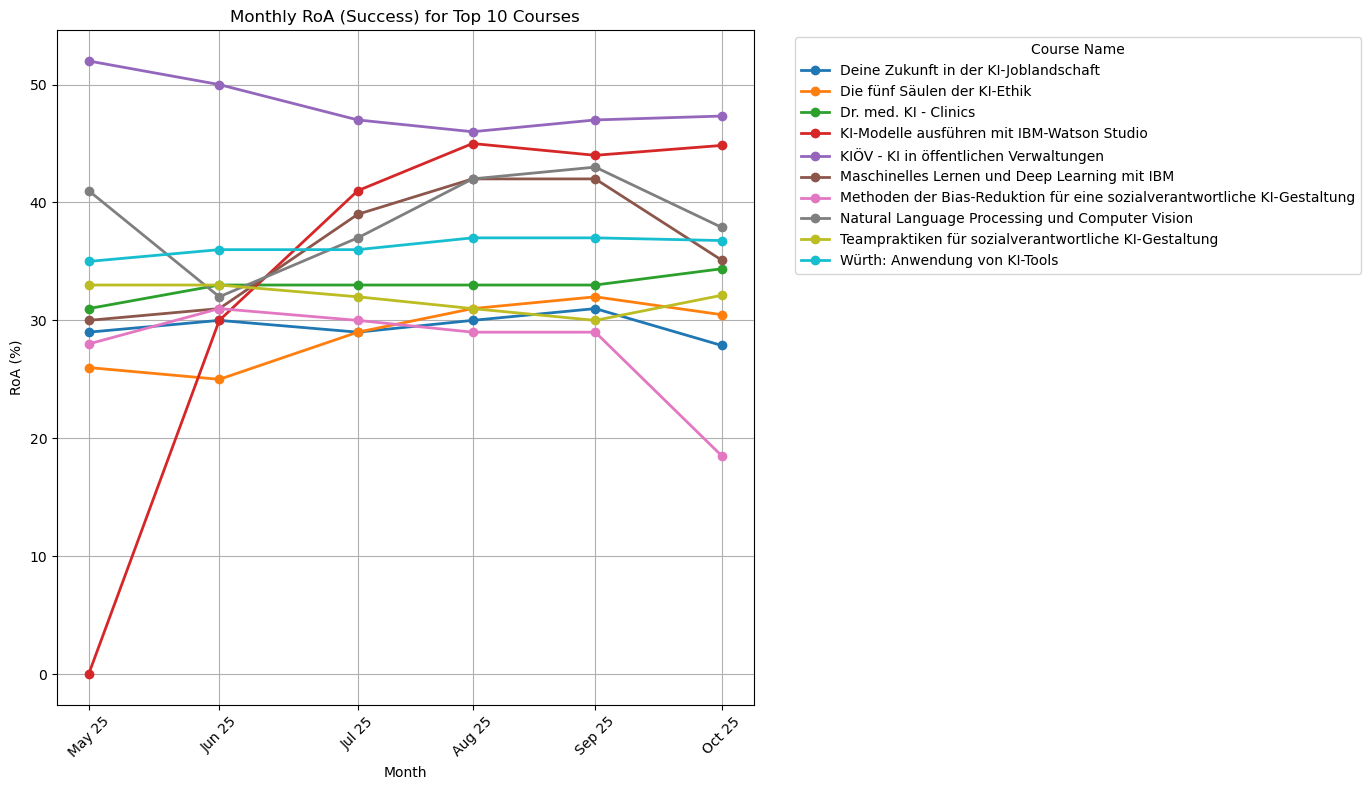

In [268]:

# print the top-10 RoA time-series analysis section
question_6 = (
    "How does the Rate of Achievement (RoA) develop over time for the "
    "Top-10 highest-RoA courses, and what trends can be observed?"
)

summaries_6, table_rows_6, narrative_6 = analyze_top10_roa_timeseries(combined_df)

print_section(question_6, narrative_6, table_rows_6)

# run plots
plot_top10_roa_time_series(combined_df)



# ANALYSIS QUESTION: top-10 categories by total enrolments

In [269]:
### Top 10 Best Course Categories by Total Enrolments (including number of courses) ###

# 1. Compute total enrolments per category
category_enrolments = (
    combined_df.groupby("Course_Category")["Enrolled_learners"]
    .sum()
)

# 2. Count how many courses are in each category
category_counts = (
    combined_df.groupby("Course_Category")["Live_Courses"]
    .nunique()
)

# 3. Combine both into a single DataFrame
category_stats = pd.DataFrame({
    "Total Enrolments": category_enrolments,
    "Number of Courses": category_counts
})

# 4. Select Top-10 categories by enrolments
top10_categories = (
    category_stats.sort_values("Total Enrolments", ascending=False)
    .head(10)
)




In [270]:
# create table: categories + respective enrolments, no. of courses, total RoA and RoA rate

category_stats = (
    combined_df
    .groupby("Course_Category")
    .agg(
        Total_Enrolments = ("Enrolled_learners", "sum"),
        Number_of_courses = ("Live_Courses", "nunique"),
        Total_RoA = ("Acquired_#_Records_of_Achievement", "sum")
    )
    .reset_index()
)

# Convert totals to integers
category_stats["Total_Enrolments"] = category_stats["Total_Enrolments"].astype(int)
category_stats["Total_RoA"] = category_stats["Total_RoA"].astype(int)

# Numeric RoA rate (%)
category_stats["RoA_Rate"] = (
    (category_stats["Total_RoA"] / category_stats["Total_Enrolments"])
    .fillna(0)
    .replace([np.inf, -np.inf], 0)
    * 100
).round(0).astype(int)

# String version with % for display
category_stats["RoA_Rate_str"] = (
    category_stats["RoA_Rate"].astype(str) + "%"
)






In [271]:
# no!!! this is ca v enrol v roa, too much
def analyze_category_timeseries(combined_df):

    df = combined_df.copy()
    df = df.sort_values("Date")
    df["MonthLabel"] = df["Date"].dt.strftime("%b %y")

    summaries = []

    # group by category
    for category, group in df.groupby("Course_Category"):

        group = group.sort_values("Date")

        # monthly totals
        monthly = (
            group.groupby("Date")
            .agg(
                Enrolments=("Enrolled_learners", "sum"),
                RoA_total=("Acquired_#_Records_of_Achievement", "sum")
            )
            .reset_index()
        )

        monthly["RoA_rate"] = (
            monthly["RoA_total"] / monthly["Enrolments"].replace(0, np.nan)
        ) * 100
        monthly["RoA_rate"] = monthly["RoA_rate"].fillna(0)

        # peak + low (enrolments)
        peak_e = monthly.loc[monthly["Enrolments"].idxmax()]
        low_e  = monthly.loc[monthly["Enrolments"].idxmin()]

        # peak + low (RoA)
        peak_r = monthly.loc[monthly["RoA_rate"].idxmax()]
        low_r  = monthly.loc[monthly["RoA_rate"].idxmin()]

        # month formatting
        peak_e_month = peak_e["Date"].strftime("%b %y")
        low_e_month  = low_e["Date"].strftime("%b %y")
        peak_r_month = peak_r["Date"].strftime("%b %y")
        low_r_month  = low_r["Date"].strftime("%b %y")

        # enrolment trend
        start_e = monthly["Enrolments"].iloc[0]
        end_e   = monthly["Enrolments"].iloc[-1]

        if end_e > start_e:
            enrol_trend = "increasing"
        elif end_e < start_e:
            enrol_trend = "decreasing"
        else:
            enrol_trend = "stable"

        # RoA trend
        start_r = monthly["RoA_rate"].iloc[0]
        end_r   = monthly["RoA_rate"].iloc[-1]

        if end_r > start_r:
            roa_trend = "increasing"
        elif end_r < start_r:
            roa_trend = "decreasing"
        else:
            roa_trend = "stable"

        summaries.append(
            {
                "Category": category,
                "Peak_Enrolments": int(peak_e["Enrolments"]),
                "Peak_Enrolments_Month": peak_e_month,
                "Low_Enrolments": int(low_e["Enrolments"]),
                "Low_Enrolments_Month": low_e_month,
                "Peak_RoA": round(float(peak_r["RoA_rate"]), 2),
                "Peak_RoA_Month": peak_r_month,
                "Low_RoA": round(float(low_r["RoA_rate"]), 2),
                "Low_RoA_Month": low_r_month,
                "Enrolment_Trend": enrol_trend,
                "RoA_Trend": roa_trend,
            }
        )

    # global lists for narrative
    inc_enrol  = [s["Category"] for s in summaries if s["Enrolment_Trend"] == "increasing"]
    dec_enrol  = [s["Category"] for s in summaries if s["Enrolment_Trend"] == "decreasing"]
    stable_enr = [s["Category"] for s in summaries if s["Enrolment_Trend"] == "stable"]

    inc_roa  = [s["Category"] for s in summaries if s["RoA_Trend"] == "increasing"]
    dec_roa  = [s["Category"] for s in summaries if s["RoA_Trend"] == "decreasing"]
    stable_roa = [s["Category"] for s in summaries if s["RoA_Trend"] == "stable"]

    # summary table (compatible with print_table)
    table_rows = [
        ("Total Categories", str(len(summaries))),
        ("Increasing Enrolments", str(len(inc_enrol))),
        ("Decreasing Enrolments", str(len(dec_enrol))),
        ("Stable Enrolments",     str(len(stable_enr))),
        ("Increasing RoA", str(len(inc_roa))),
        ("Decreasing RoA", str(len(dec_roa))),
        ("Stable RoA",     str(len(stable_roa))),
    ]

    # narrative text
    narrative = (
        "This category-level time-series analysis examines how enrolments and RoA evolve "
        "over multiple months for each course category.\n\n"
        f"**Enrolment Trends:**\n"
        f"- Increasing: {', '.join(inc_enrol) if inc_enrol else 'None'}\n"
        f"- Decreasing: {', '.join(dec_enrol) if dec_enrol else 'None'}\n"
        f"- Stable: {', '.join(stable_enr) if stable_enr else 'None'}\n\n"
        f"**RoA Trends:**\n"
        f"- Increasing: {', '.join(inc_roa) if inc_roa else 'None'}\n"
        f"- Decreasing: {', '.join(dec_roa) if dec_roa else 'None'}\n"
        f"- Stable: {', '.join(stable_roa) if stable_roa else 'None'}\n\n"
        "These findings highlight structural differences across learning categories: "
        "some categories gain traction with learners, while others experience declining "
        "participation or fluctuating success outcomes."
    )

    return summaries, table_rows, narrative


In [272]:
summaries, table_rows, narrative = analyze_category_timeseries(combined_df)

print_section(
    "Is there a correlation between course category and enrolments / RoA",
    narrative,
    table_rows
)


DATE: 2025-12-08

Is there a correlation between course category and enrolments / RoA


Summary Table
-------------
Metric                | Value
----------------------+---
Total Categories      | 11
Increasing Enrolments | 10
Decreasing Enrolments | 1 
Stable Enrolments     | 0 
Increasing RoA        | 9 
Decreasing RoA        | 2 
Stable RoA            | 0 

Interpretation
--------------
This category-level time-series analysis examines how enrolments and RoA evolve over multiple months for each course category.

**Enrolment Trends:**
- Increasing: Data Literacy, Handel, Industrie 4.0, KI und Ethik, Maschinelles Lernen, Medizin, Robotik, Schule, Studieren, Über KI
- Decreasing: Erwachsenenbildung
- Stable: None

**RoA Trends:**
- Increasing: Data Literacy, Handel, Industrie 4.0, KI und Ethik, Maschinelles Lernen, Robotik, Schule, Studieren, Über KI
- Decreasing: Erwachsenenbildung, Medizin
- Stable: None

These findings highlight structural differences across learning categories: som

In [273]:

# Sort + Select top 10

category_stats = category_stats.sort_values("Total_Enrolments", ascending=False)

top10_table = category_stats.head(10).reset_index(drop=True)

top10_table

,Course_Category,Total_Enrolments,Number_of_courses,Total_RoA,RoA_Rate,RoA_Rate_str
0,Über KI,130807,17,15974,12,12%
1,Studieren,65877,19,15928,24,24%
2,Industrie 4.0,46875,10,3878,8,8%
3,Erwachsenenbildung,44869,4,4036,9,9%
4,Schule,42067,12,4470,11,11%
5,Medizin,36271,10,6058,17,17%
6,KI und Ethik,27523,5,5406,20,20%
7,Maschinelles Lernen,27028,11,2451,9,9%
8,Data Literacy,24056,6,2789,12,12%
9,Handel,7697,1,1149,15,15%


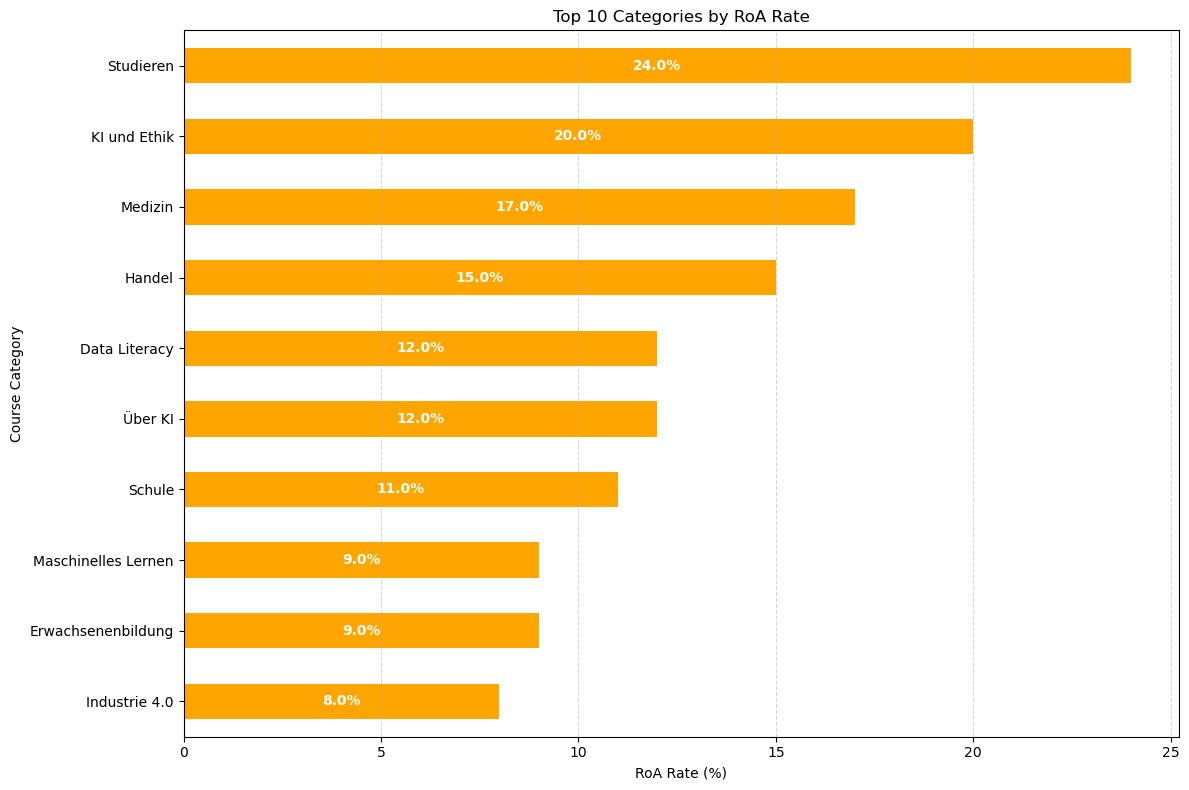

In [274]:
plt.figure(figsize=(12, 8))

data = (
    top10_table
    .set_index("Course_Category")
    .sort_values("RoA_Rate")
)

ax = data["RoA_Rate"].plot(kind="barh", color="orange")

plt.title("Top 10 Categories by RoA Rate")
plt.xlabel("RoA Rate (%)")
plt.ylabel("Course Category")
plt.grid(axis="x", linestyle="--", alpha=0.5)

# Add labels: display the rate as a % inside the bar
for i, value in enumerate(data["RoA_Rate"]):
    ax.text(
        value * 0.5,
        i,
        f"{value:.1f}%",
        va="center", ha="center",
        color="white", fontsize=10, fontweight="bold"
    )

plt.tight_layout()
plt.show()


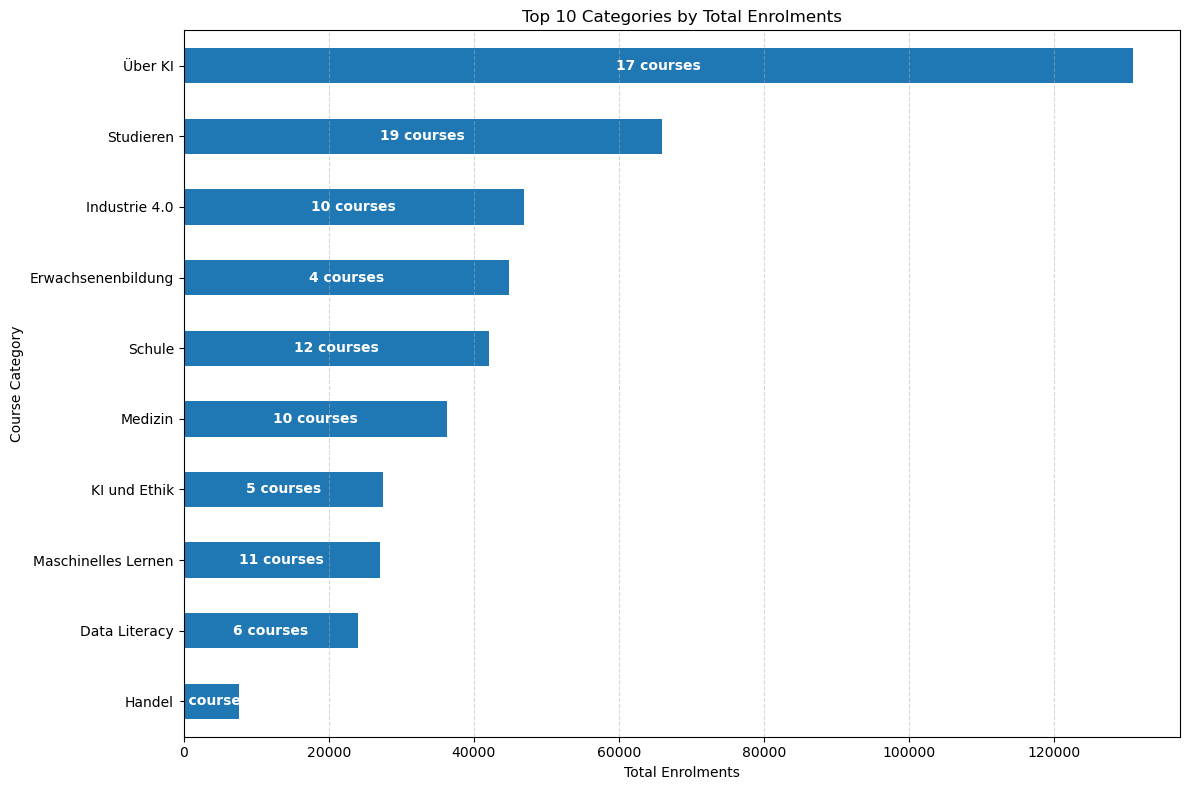

In [275]:

# Plot

plt.figure(figsize=(12, 8))

data = (
    top10_table
    .set_index("Course_Category")
    .sort_values("Total_Enrolments")
)

ax = data["Total_Enrolments"].plot(kind="barh")

plt.title("Top 10 Categories by Total Enrolments")
plt.xlabel("Total Enrolments")
plt.ylabel("Course Category")
plt.grid(axis="x", linestyle="--", alpha=0.5)

# Add annotations: number of courses inside bars
for i, (value, num_courses) in enumerate(zip(data["Total_Enrolments"], data["Number_of_courses"])):
    ax.text(
        value * 0.5,   # halfway inside the bar
        i, 
        f"{num_courses} courses",
        va="center", ha="center", color="white", fontsize=10, fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ANALYSIS QUESTION: correlation: enrolments v RoA

In [276]:
# Ensure numeric types
df = combined_df.copy()
df["Enrolled_learners"] = pd.to_numeric(df["Enrolled_learners"], errors="coerce")
df["Rate_RoA_(success)"] = pd.to_numeric(df["Rate_RoA_(success)"], errors="coerce")

# Drop rows with missing values
df = df.dropna(subset=["Enrolled_learners", "Rate_RoA_(success)"])

# Pearson correlation (linear)
pearson_corr = df["Enrolled_learners"].corr(df["Rate_RoA_(success)"])

# Spearman correlation (monotonic trends)
spearman_corr = df["Enrolled_learners"].corr(df["Rate_RoA_(success)"], method="spearman")





In [277]:
# main analysis function
def analyze_enrolment_roa_correlation(combined_df):

    df = combined_df.copy()

    # Ensure numeric
    df["Enrolled_learners"] = pd.to_numeric(df["Enrolled_learners"], errors="coerce")
    df["Rate_RoA_(success)"] = pd.to_numeric(df["Rate_RoA_(success)"], errors="coerce")
    df["Date"] = pd.to_datetime(df["Date"])

    df = df.dropna(subset=["Enrolled_learners", "Rate_RoA_(success)"])

    # ---- Global correlations ----
    pearson = df["Enrolled_learners"].corr(df["Rate_RoA_(success)"])
    spearman = df["Enrolled_learners"].corr(df["Rate_RoA_(success)"], method="spearman")

    # ---- Category-level correlations ----
    category_corr = (
        df.groupby("Course_Category")[["Enrolled_learners", "Rate_RoA_(success)"]]
        .corr()
        .unstack()
        .iloc[:, 1]       # correlation column for RoA vs Enrolments
        .dropna()
        .sort_values()
    )

    # ---- Monthly correlations ----
    monthly_corr = (
        df.groupby("Month")[["Enrolled_learners", "Rate_RoA_(success)"]]
        .corr()
        .unstack()
        .iloc[:, 1]
        .dropna()
        .sort_index()
    )

    # ---- Per-course contribution to correlation ----
    course_corr = (
        df.groupby("Live_Courses")[["Enrolled_learners", "Rate_RoA_(success)"]]
        .corr()
        .unstack()
        .iloc[:, 1]
        .dropna()
        .sort_values()
    )

    # ---- Build summary rows (for your print_table) ----
    table_rows = [
        ("Pearson Correlation", f"{pearson:.4f}"),
        ("Spearman Correlation", f"{spearman:.4f}"),
        ("# Categories with positive corr.", str((category_corr > 0).sum())),
        ("# Categories with negative corr.", str((category_corr < 0).sum())),
        ("Strongest positive category", category_corr.idxmax() + f" ({category_corr.max():.3f})"),
        ("Strongest negative category", category_corr.idxmin() + f" ({category_corr.min():.3f})"),
    ]

    # ---- Narrative for print_section ----
    narrative = (
        f"The correlation between Enrolments and RoA was analysed across all courses.\n\n"
        f"Globally, the Pearson correlation is {pearson:.3f}, while the Spearman "
        f"correlation is {spearman:.3f}. Pearson measures linear association, whereas "
        f"Spearman captures monotonic relationships. Values close to zero indicate no "
        f"relationship, positive values indicate that higher enrolments tend to be "
        f"associated with higher RoA, and negative values imply that large courses "
        f"tend to achieve lower RoA.\n\n"
        f"Across categories, correlations vary substantially. { (category_corr>0).sum() } "
        f"categories show a positive association, while { (category_corr<0).sum() } "
        f"show a negative association. The strongest positive category is "
        f"'{category_corr.idxmax()}' with correlation {category_corr.max():.3f}, "
        f"whereas the strongest negative category is '{category_corr.idxmin()}' "
        f"with correlation {category_corr.min():.3f}.\n\n"
        f"Month-by-month correlation analysis indicates how the relationship evolves "
        f"over time and helps detect structural changes in learner behaviour or course "
        f"design. Per-course correlations reveal which courses most strongly influence "
        f"the global trend, distinguishing between scalable high-performing courses and "
        f"those whose RoA drops under heavy enrolment.\n\n"
        f"Overall, this analysis provides a multi-level understanding of the interplay "
        f"between course popularity and learner success."
    )

    return table_rows, narrative, category_corr, monthly_corr, course_corr

# activation code
table_rows, narrative, category_corr, monthly_corr, course_corr = \
    analyze_enrolment_roa_correlation(combined_df)


In [278]:
# reporting function (using the helper functions)
def print_enrolment_roa_report(table_rows, narrative):
    print_section(
        "Correlation Between Enrolments and RoA",
        narrative,
        table_rows
    )

# usage of the reporting function
table_rows, narrative, category_corr, monthly_corr, course_corr = \
    analyze_enrolment_roa_correlation(combined_df)


print_enrolment_roa_report(table_rows, narrative)


DATE: 2025-12-08

Correlation Between Enrolments and RoA


Summary Table
-------------
Metric                           | Value                     
---------------------------------+---------------------------
Pearson Correlation              | 0.1519                    
Spearman Correlation             | 0.5190                    
# Categories with positive corr. | 4                         
# Categories with negative corr. | 7                         
Strongest positive category      | Erwachsenenbildung (0.863)
Strongest negative category      | KI und Ethik (-0.857)     

Interpretation
--------------
The correlation between Enrolments and RoA was analysed across all courses.

Globally, the Pearson correlation is 0.152, while the Spearman correlation is 0.519. Pearson measures linear association, whereas Spearman captures monotonic relationships. Values close to zero indicate no relationship, positive values indicate that higher enrolments tend to be associated with higher RoA, an

In [279]:
# Pearson and Spearman
pearson_corr, spearman_corr

(0.15188350633717948, 0.5189749040689837)

In [280]:
# per-category correlation
category_corr = (
    df.groupby("Course_Category")[["Enrolled_learners", "Rate_RoA_(success)"]]
      .corr()
      .unstack()
      .iloc[:, 1]                 # the correlation numbers
      .to_frame("Corr_Enrol_RoA") # <-- NOW the column has a real name
)



category_corr


,Corr_Enrol_RoA
Course_Category,
Data Literacy,-0.143322
Erwachsenenbildung,0.863430
Handel,0.579396
Industrie 4.0,-0.056563
KI und Ethik,-0.857374
Maschinelles Lernen,-0.220593
Medizin,-0.006498
Robotik,0.715390
Schule,-0.266721


In [281]:

# top-/bottom- contributor courses
def print_course_correlation_extremes(course_corr, n=5):
    print("\nTop Courses (positive corr.):")
    print(course_corr.tail(n))

    print("\nBottom Courses (negative corr.):")
    print(course_corr.head(n))

print_course_correlation_extremes(course_corr)



Top Courses (positive corr.):
Live_Courses
AI4Democracy - Grundlagen zu KI in der Demokratie                  0.973922
Prompt-Labor Hochschullehre 2.0                                    0.988211
Prompt-Labor – generative KI in der Hochschullehre: Anwendungen    1.000000
Methods of AI I – Intelligent Agents                               1.000000
Methods of AI III – Logical Reasoning                              1.000000
Name: (Enrolled_learners, Rate_RoA_(success)), dtype: float64

Bottom Courses (negative corr.):
Live_Courses
Methods of AI – Machine Learning                                       -1.000000
Methods of AI IV – Knowledge Representation                            -1.000000
Methods of AI II – Search Algorithms                                   -1.000000
Methods of AI V – Constraint Reasoning                                 -1.000000
Dr. med. KI - Micro Degree zu Künstlicher Intelligenz in der Medizin   -0.992395
Name: (Enrolled_learners, Rate_RoA_(success)), dtype: float64


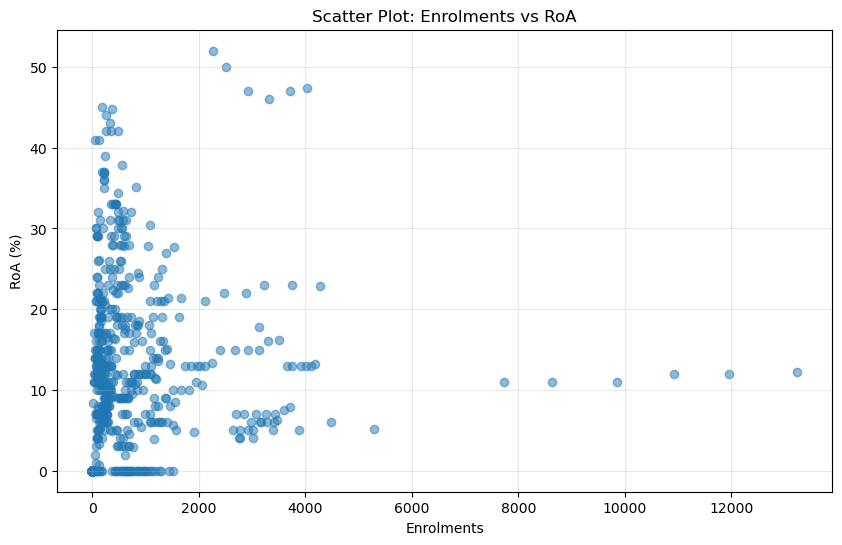

In [282]:
# double-checking numeric conversion

def plot_enrolment_roa_scatter(combined_df):

    plt.figure(figsize=(10,6))
    plt.scatter(df["Enrolled_learners"], df["Rate_RoA_(success)"], alpha=0.5)
    plt.xlabel("Enrolments")
    plt.ylabel("RoA (%)")
    plt.title("Scatter Plot: Enrolments vs RoA")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_enrolment_roa_scatter(combined_df)




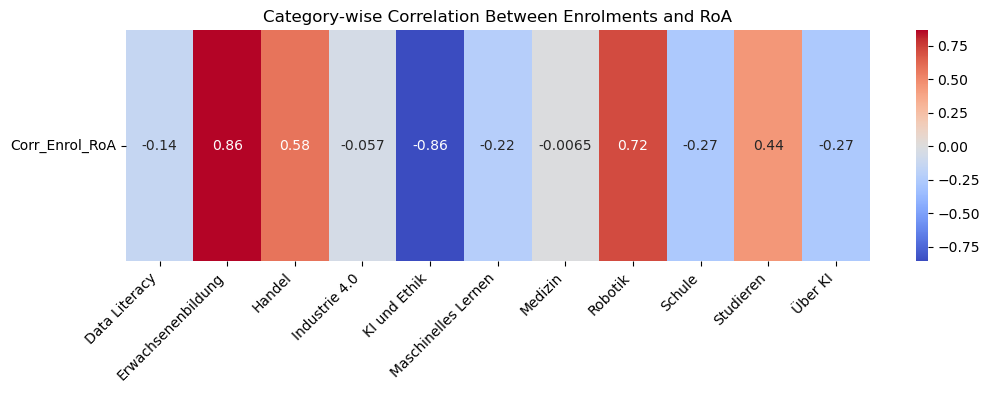

In [283]:
# heatmap of category correlations

def plot_category_corr_heatmap(category_corr):

    # Ensure we have a 1-row DataFrame with a proper row name
    if isinstance(category_corr, pd.Series):
        df = category_corr.to_frame(name="Corr_Enrol_RoA").T
    else:
        df = category_corr.copy().T
        df.index = ["Corr_Enrol_RoA"]
        df.columns.name = None  # remove annoying "None" label
    
    plt.figure(figsize=(12,3))
    sns.heatmap(
        df,
        annot=True,
        cmap="coolwarm",
        center=0
    )
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.title("Category-wise Correlation Between Enrolments and RoA")
    plt.ylabel("")   # clean y-axis
    plt.show()


plot_category_corr_heatmap(category_corr)


In [284]:
# top-/bottom- contributor courses
def print_course_correlation_extremes(course_corr, n=5):
    print("\nTop Courses (positive corr.):")
    print(course_corr.tail(n))

    print("\nBottom Courses (negative corr.):")
    print(course_corr.head(n))

print_course_correlation_extremes(course_corr)



Top Courses (positive corr.):
Live_Courses
AI4Democracy - Grundlagen zu KI in der Demokratie                  0.973922
Prompt-Labor Hochschullehre 2.0                                    0.988211
Prompt-Labor – generative KI in der Hochschullehre: Anwendungen    1.000000
Methods of AI I – Intelligent Agents                               1.000000
Methods of AI III – Logical Reasoning                              1.000000
Name: (Enrolled_learners, Rate_RoA_(success)), dtype: float64

Bottom Courses (negative corr.):
Live_Courses
Methods of AI – Machine Learning                                       -1.000000
Methods of AI IV – Knowledge Representation                            -1.000000
Methods of AI II – Search Algorithms                                   -1.000000
Methods of AI V – Constraint Reasoning                                 -1.000000
Dr. med. KI - Micro Degree zu Künstlicher Intelligenz in der Medizin   -0.992395
Name: (Enrolled_learners, Rate_RoA_(success)), dtype: float64


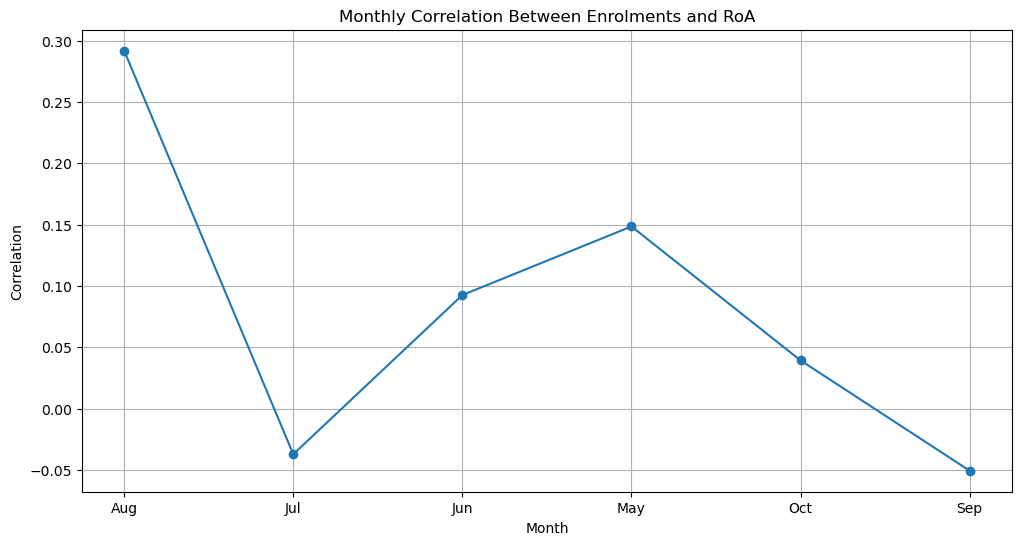

In [285]:
# monthly correlation line chart
def plot_monthly_corr(monthly_corr):
    plt.figure(figsize=(12,6))
    monthly_corr.plot(marker="o")
    plt.title("Monthly Correlation Between Enrolments and RoA")
    plt.xlabel("Month")
    plt.ylabel("Correlation")
    plt.grid(True)
    plt.show()

plot_monthly_corr(monthly_corr)
